# 二手车价格预测分析报告

本报告使用训练集 `used_car_train_20200313.csv` 和测试集 `used_car_testA_20200313.csv`，
围绕二手车成交价格 `price` 建立回归预测模型。报告按需求分析、数据预处理、数据业务分析/可视化分析、
算法建模、项目结论五个部分组织。

## 1. 需求分析

本项目的目标是根据车辆基础属性、交易信息和匿名特征预测二手车交易价格。预测目标 `price`
是连续数值，因此这是一个典型的回归预测任务。模型效果使用 MAE（Mean Absolute Error，平均绝对误差）
评价，MAE 越小表示预测价格与真实价格越接近。

MAE 公式：

$$MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path(r"C:\Users\y2003\Downloads")
TRAIN_PATH = BASE_DIR / "used_car_train_20200313.csv"
TEST_PATH = BASE_DIR / "used_car_testA_20200313.csv"
RANDOM_STATE = 42

基础库导入完成，随机种子设置为 42。


In [2]:
train_raw = pd.read_csv(TRAIN_PATH, dtype=str)
test_raw = pd.read_csv(TEST_PATH, sep=r"\s+", engine="python", dtype=str)

print("训练集 shape:", train_raw.shape)
print("测试集 shape:", test_raw.shape)
print("训练集是否包含 price:", "price" in train_raw.columns)
print("测试集是否包含 price:", "price" in test_raw.columns)
train_raw.head()

训练集 shape: (150000, 31)
测试集 shape: (50000, 30)
训练集是否包含 price: True
测试集是否包含 price: False


SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,regionCode,seller,offerType,creatDate,price,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,736,20040402,30,6,1,0,0,60,12.5,0,1046,0,0,20160404,1850,43.35779631,3.966344166,0.050257094,2.159744094,1.143786187,0.235675907,0.101988241,0.129548661,0.022816367,0.097461829,-2.881803239,2.804096771,-2.420820793,0.795291943,0.9147625
1,2262,20030301,40,1,2,0,0,0,15,-,4366,0,0,20160309,3600,45.30527302,5.236111898,0.137925324,1.38065746,-1.422164921,0.264777256,0.121003594,0.135730707,0.026597448,0.020581663,-4.900481882,2.096337644,-1.030482837,-1.722673775,0.245522411
2,14874,20040403,115,15,1,0,0,163,12.5,0,2806,0,0,20160402,6222,45.97835906,4.823792215,1.319524152,-0.998467274,-0.996911035,0.251410148,0.114912277,0.165147493,0.062172837,0.027074824,-4.84674926,1.803558941,1.565329625,-0.832687327,-0.229962856
3,71865,19960908,109,10,0,0,1,193,15,0,434,0,0,20160312,2400,45.6874782,4.492574134,-0.050615843,0.883599671,-2.228078725,0.274293171,0.110300085,0.121963746,0.033394547,0,-4.509598824,1.285939744,-0.501867908,-2.438352737,-0.478699379
4,111080,20120103,110,5,1,0,0,68,5,0,6977,0,0,20160313,5200,44.38351084,2.031433258,0.572168948,-1.571239028,2.246088325,0.228035622,0.073205054,0.091880479,0.078819385,0.121534241,-1.896240279,0.910783134,0.931109559,2.83451782,1.923481963


## 2. 数据预处理

原始数据中存在 `-` 表示的缺失值；另外训练集中有少量记录出现字段错位，例如 `seller`、`offerType`
本应为 0/1，却出现日期或价格等不合法值。为保证模型学习到稳定关系，本报告采用保守清洗策略：

- 将 `-` 替换为缺失值；
- 删除 `seller`、`offerType` 不在合法取值范围内的错位记录；
- 删除 `price` 缺失或小于 0 的样本；
- 建模阶段使用中位数填充剩余缺失值。

In [3]:
train = train_raw.replace("-", np.nan).copy()
legal_schema = train["seller"].isin(["0", "1"]) & train["offerType"].isin(["0", "1"])
schema_shift_removed = (~legal_schema).sum()
train = train[legal_schema].copy()

for col in train.columns:
    train[col] = pd.to_numeric(train[col], errors="coerce")

legal_price = train["price"].notna() & (train["price"] >= 0)
invalid_price_removed = (~legal_price).sum()
train = train[legal_price].copy()

test = test_raw.replace("-", np.nan).copy()
for col in test.columns:
    test[col] = pd.to_numeric(test[col], errors="coerce")

print("原始训练样本数:", len(train_raw))
print("字段错位过滤数:", schema_shift_removed)
print("无效价格过滤数:", invalid_price_removed)
print("清洗后训练样本数:", len(train))

原始训练样本数: 150000
字段错位过滤数: 14116
无效价格过滤数: 0
清洗后训练样本数: 135884


In [4]:
missing_summary = (
    train_raw.replace("-", np.nan)
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .rename("missing_count")
    .to_frame()
)
missing_summary

,missing_count
notRepairedDamage,17558
v_14,14116
kilometer,4191
v_13,3583
v_12,1469
gearbox,1387
power,1188
fuelType,0


## 3. 数据业务分析 / 可视化分析

从业务角度看，二手车价格通常受车龄、里程、功率、车型品牌和车况影响。匿名特征 `v_0` 到 `v_14`
虽然无法直接解释业务含义，但可以作为模型的重要数值输入。下面通过缺失值、价格分布、相关性等图表
观察数据特征。

In [5]:
field_table = pd.DataFrame(
    [
        ["SaleID", "交易ID，唯一编码", "仅用于关联和提交，不入模"],
        ["regDate / creatDate", "注册日期 / 上线日期", "提取年月日，构造车龄"],
        ["power / kilometer", "发动机功率 / 行驶公里", "截断异常功率，构造功率里程比"],
        ["seller / offerType", "销售方 / 报价类型", "过滤非法错位值"],
        ["v_0 - v_14", "匿名特征", "作为连续数值特征入模"],
    ],
    columns=["字段", "含义", "处理方式"],
)
field_table

字段,含义,处理方式
SaleID,交易ID，唯一编码,仅用于关联和提交，不入模
regDate / creatDate,注册日期 / 上线日期,提取年月日，构造车龄
power / kilometer,发动机功率 / 行驶公里,截断异常功率，构造功率里程比
seller / offerType,销售方 / 报价类型,过滤非法错位值
v_0 - v_14,匿名特征,作为连续数值特征入模


### 缺失值统计图

notRepairedDamage 等字段缺失较多，后续通过中位数填充进入模型。

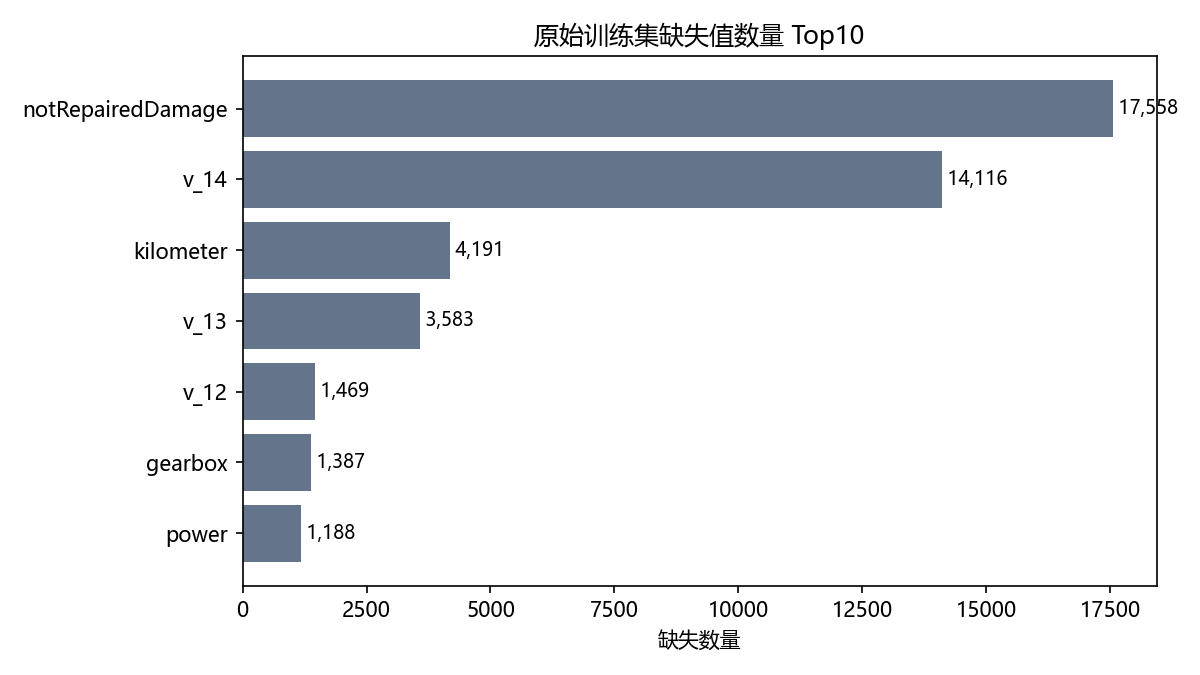

In [6]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\missing_values.png"))

### 价格分布图

价格呈明显长尾分布，低价车占多数，高价车数量较少。

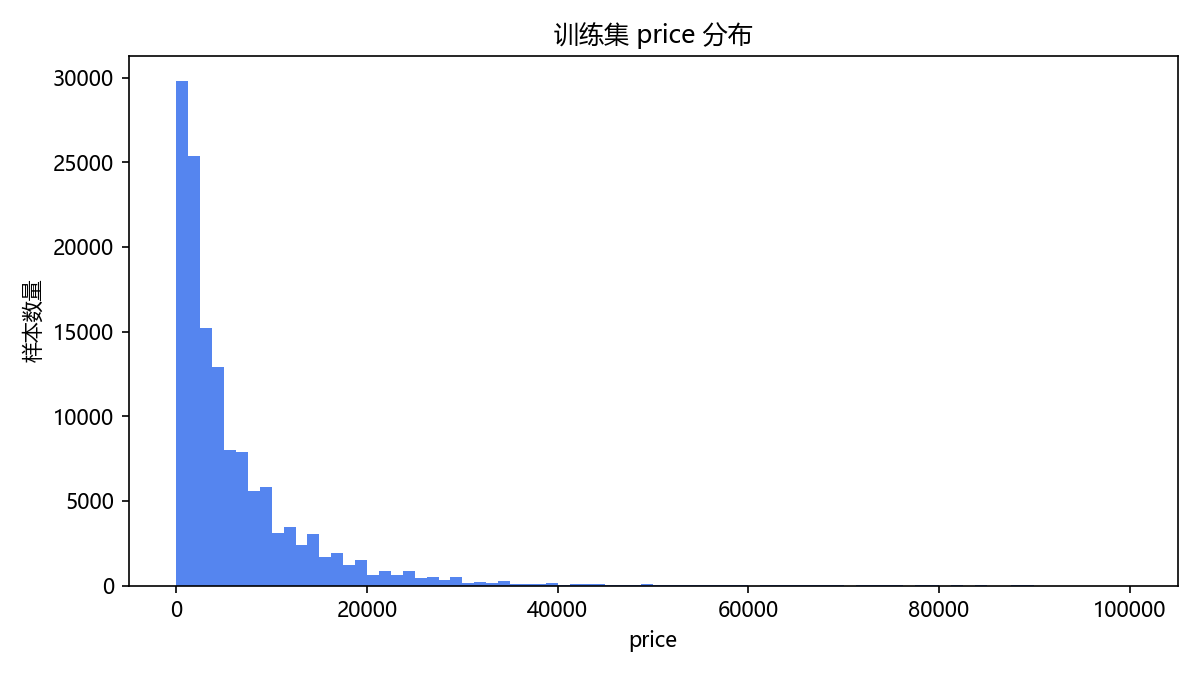

In [7]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\price_distribution.png"))

### log1p(price) 分布图

对数变换后价格分布更平滑，说明原始价格存在长尾。

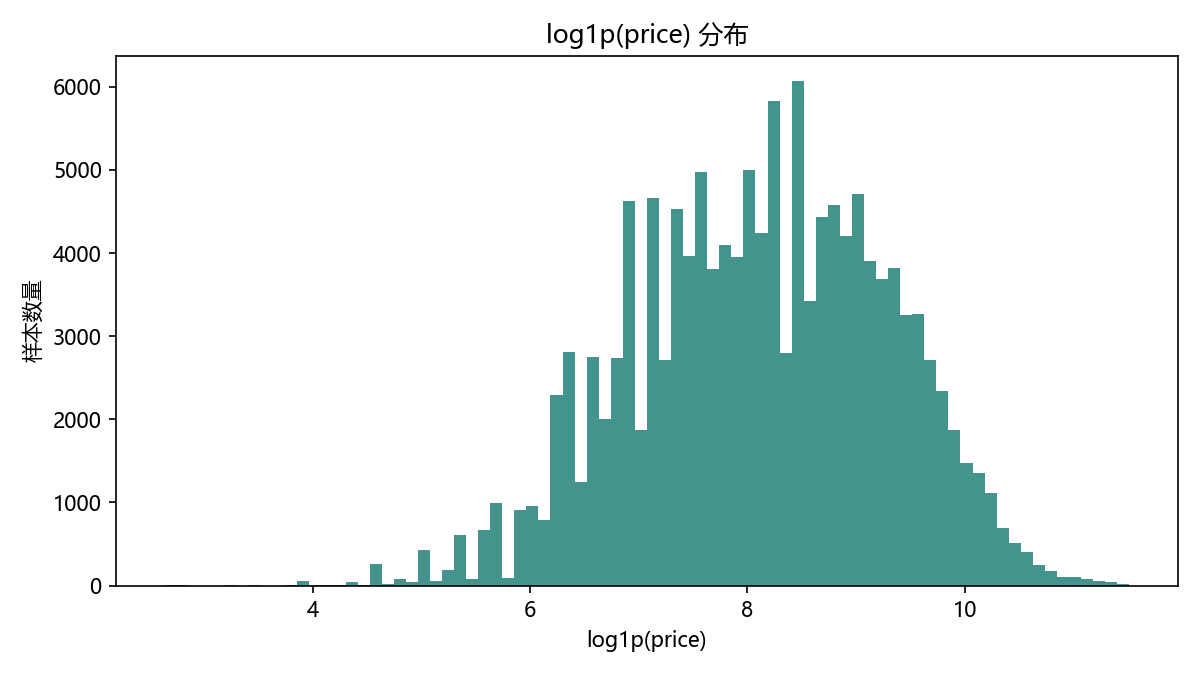

In [8]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\log_price_distribution.png"))

### 关键特征相关性图

匿名特征和车辆属性中存在与 price 相关性较高的变量。

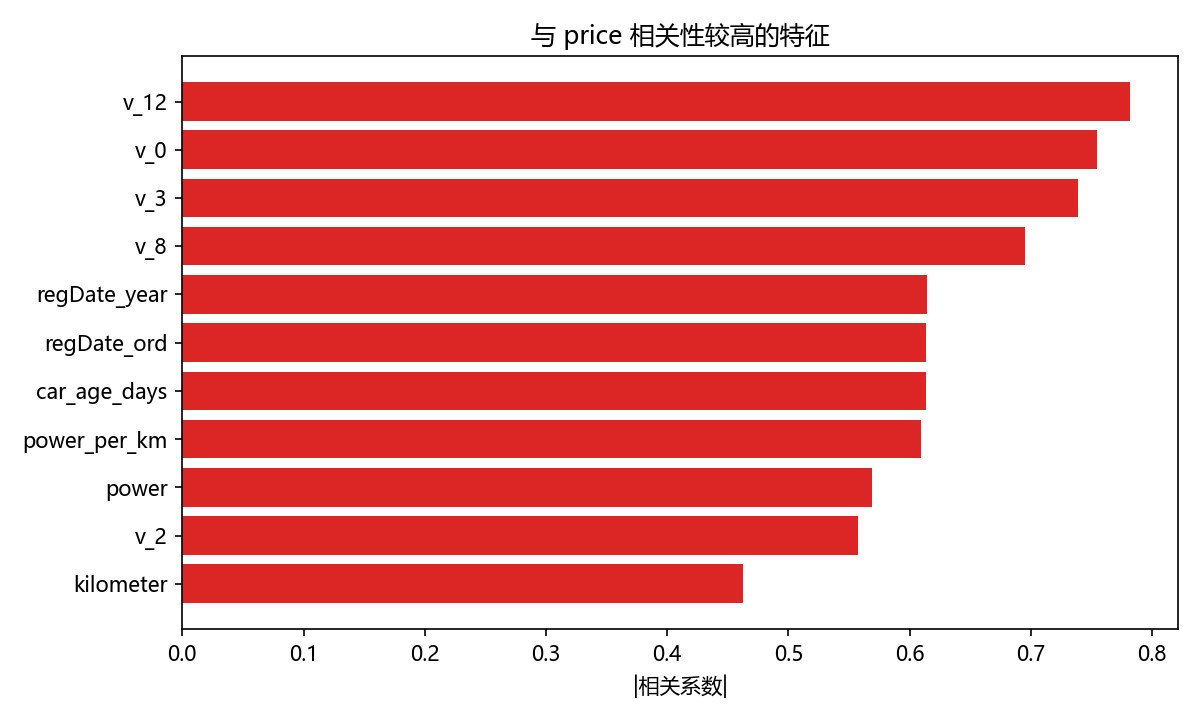

In [9]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\top_correlations.png"))

## 4. 算法建模

建模阶段先构造日期和业务组合特征，再比较线性 baseline 与随机森林主模型。Ridge 模型用于建立简单参照，
RandomForest 可以捕捉非线性关系和特征交互，更适合本题的复杂价格关系。

In [10]:
def parse_yyyymmdd(series):
    values = pd.to_numeric(series, errors="coerce")
    text = values.fillna(0).astype("int64").astype(str).str.zfill(8)
    return pd.to_datetime(text, format="%Y%m%d", errors="coerce")

def add_features(df, is_train):
    data = df.copy()
    for date_col in ["regDate", "creatDate"]:
        dt = parse_yyyymmdd(data[date_col])
        data[f"{date_col}_year"] = dt.dt.year
        data[f"{date_col}_month"] = dt.dt.month
        data[f"{date_col}_day"] = dt.dt.day
        data[f"{date_col}_ord"] = dt.map(lambda x: x.toordinal() if pd.notna(x) else np.nan)

    data["car_age_days"] = data["creatDate_ord"] - data["regDate_ord"]
    data.loc[data["car_age_days"] < 0, "car_age_days"] = np.nan
    data["power"] = data["power"].clip(0, 600)
    data["power_per_km"] = data["power"] / (data["kilometer"] + 1)

    drop_cols = ["SaleID", "name", "regDate", "creatDate"]
    if is_train:
        drop_cols.append("price")
    return data.drop(columns=drop_cols)

X = add_features(train, is_train=True)
X_test = add_features(test, is_train=False)[X.columns]
y = train["price"].astype(float)

print("特征数量:", X.shape[1])
print("训练/测试特征一致:", list(X.columns) == list(X_test.columns))

特征数量: 36
训练/测试特征一致: True


In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

models = {
    "Ridge 基线模型": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=20.0)),
    ]),
    "RandomForest 主模型": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=22,
            min_samples_leaf=2,
            max_features=0.8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

result_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 0)
    mae = mean_absolute_error(y_valid, pred)
    result_rows.append({"模型": name, "验证集MAE": mae})

result_df = pd.DataFrame(result_rows).sort_values("验证集MAE")
result_df

模型,验证集MAE
RandomForest 主模型,622.53
Ridge 基线模型,2124.55


### 模型 MAE 对比与特征重要性

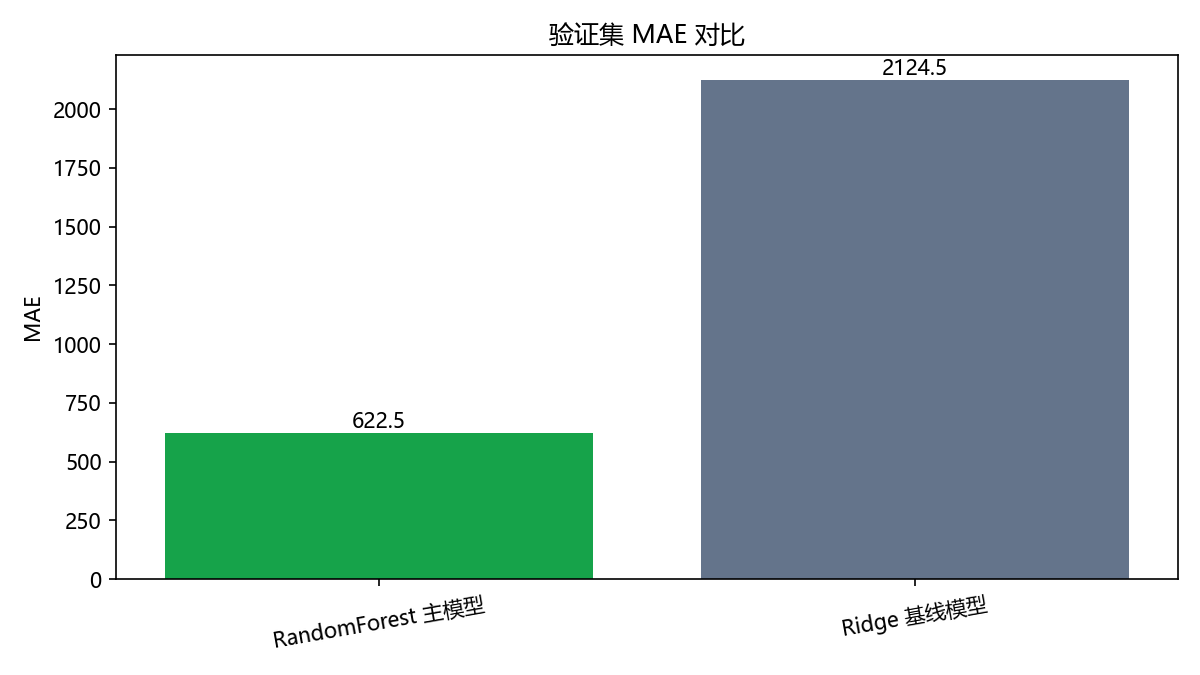

In [12]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\model_mae.png"))

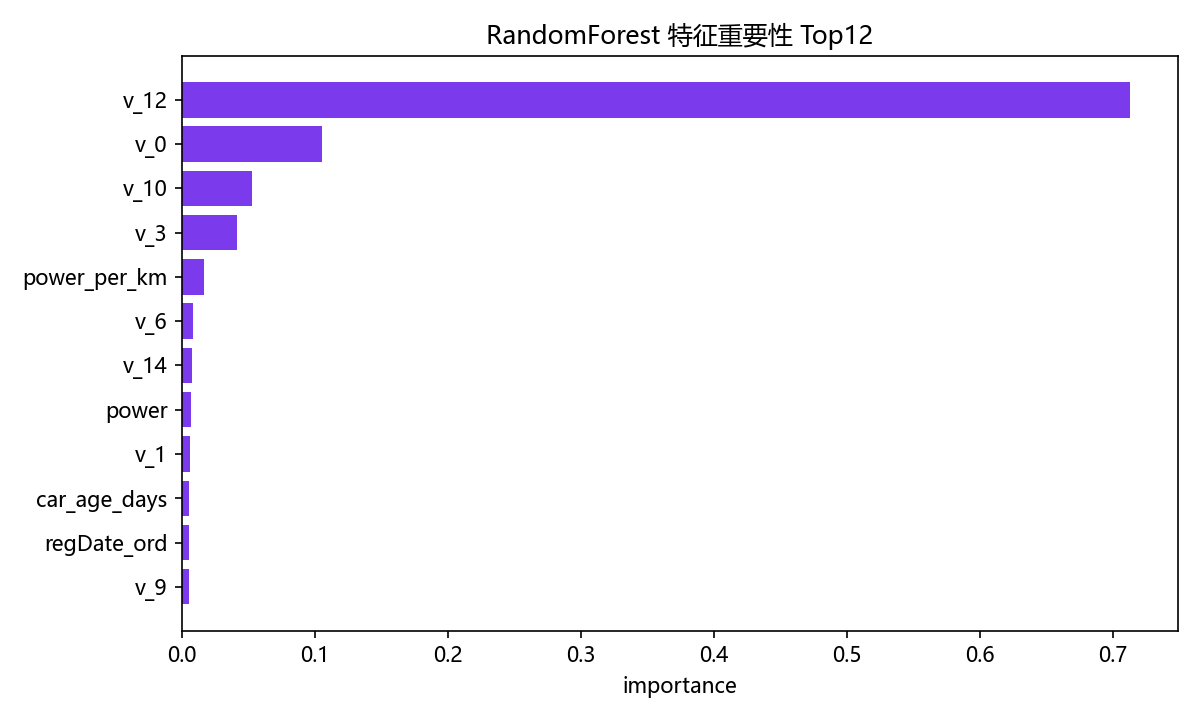

In [13]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\y2003\Downloads\outputs\used_car_notebook_report\feature_importance.png"))

## 5. 项目结论

本项目完成了从数据读取、数据清洗、业务可视化、特征工程到算法建模的完整流程。清洗后训练样本数为
**135,884** 条，最终输入特征数为 **36** 个。

模型对比结果显示，**RandomForest 主模型** 的验证集 MAE 最低，MAE 为 **622.53**。相比 Ridge
线性基线模型，随机森林能够更好地刻画二手车价格中的非线性关系，例如车龄、里程、功率与匿名特征之间的交互。

后续可以从三个方向优化：第一，引入 LightGBM 或 XGBoost 等梯度提升树模型；第二，使用交叉验证降低单次划分带来的偶然性；
第三，尝试目标对数变换、品牌/车型统计特征等更细的特征工程。所有模型均基于本地训练数据重新训练，没有使用外部成品模型或预测结果。